# CS4168 Data Mining – Group Project
## Section 1: Exploratory Data Analysis (EDA)

This notebook does exploratory data analysis of the `tracks2026.csv` dataset, which contains audio features and metadata for music tracks across multiple genres. The EDA aims to show insights that will inform our clustering and predictive modelling decisions in the next notebooks.

## A. Importing Modules and Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("./tracks2026.csv")
df.head(5)

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop


In [4]:
df.tail(5)

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1995,4pcpqfSn8tfm6vQMMZPjpM,25.0,266133,False,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,1WM80A5a4xDtlndjqjZQIv,52.0,223236,False,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,4drUfuJw6c9M5cXA8p7upO,0.0,162009,False,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,6ULjJomtdRstnT9BPMAf9d,58.0,120000,False,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop
1999,46qnV2b4tq0QqJwIoZwMyJ,25.0,244026,False,0.746,0.570,7,-10.599,1,0.0389,0.6660,0.000005,0.3200,0.657,109.929,4,synth-pop


## B. Quick Data Exploration

In [6]:
print("Shape:", df.shape)
print()
print("Column dtypes:")
print(df.dtypes)

Shape: (2000, 17)

Column dtypes:
track_id             object
popularity          float64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


The dataset has 2,000 rows and 17 columns. The columns fall into three types

- `track_id` (string) not useful for our work and will be dropped.
- Categorical: `explicit` (boolean), `key` (integer 0–11 representing pitch), `mode` (0 = minor, 1 = major), `time_signature`, `track_genre`.
- Numerical (audio features): `popularity`, `duration_ms`, `danceability`, `energy`, `loudness`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`.

Most audio features are Spotify-derived values normalised between 0 and 1, except `loudness` which seems to usually be negative and `tempo` (BPM).

In [23]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df[missing_df["Missing Count"] > 0]

,Missing Count,Missing %
popularity,40,2.00
danceability,40,2.00
energy,40,2.00
loudness,39,1.95
tempo,40,2.00


In [24]:
# Check whether missing values occur in the same rows
missing_rows = df[df.isnull().any(axis=1)]
print(f"Rows with at least one missing value: {len(missing_rows)}")
print()
print("Missing per column within those rows:")
print(missing_rows.isnull().sum()[missing_rows.isnull().sum() > 0])

Rows with at least one missing value: 40

Missing per column within those rows:
popularity      40
danceability    40
energy          40
loudness        39
tempo           40
dtype: int64


There are 40 rows with missing values. The missing values are in the same rows across `popularity`, `danceability`, `energy`, `tempo`, and `loudness`. This could suggests to us that these tracks returned no audio from Spotify so they are incomplete and should be dropped, We'll handle this all later

### B.2. Statistical Summary of Numerical Attributes

In [9]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,1960.000000,2000.000000,1960.000000,1960.000000,2000.000000,1961.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,1960.000000,2000.000000
mean,39.805102,217806.433000,0.635897,0.632489,5.295500,400.575884,0.637500,0.078466,0.297378,0.030269,0.180715,0.539963,120.040092,3.912000
std,29.245904,56804.759189,0.138298,0.189087,3.567148,18065.717039,0.480842,0.076223,0.279793,0.119946,0.149938,0.236062,28.520528,0.425848
min,0.000000,60000.000000,0.185000,0.090900,0.000000,-21.089000,0.000000,0.022100,0.000007,0.000000,0.009860,0.035900,51.037000,1.000000
25%,1.750000,181210.000000,0.548000,0.507750,2.000000,-8.988000,0.000000,0.034475,0.052475,0.000000,0.093775,0.353000,96.956000,4.000000
50%,45.000000,211346.000000,0.646000,0.644000,5.000000,-6.924000,1.000000,0.047500,0.195500,0.000007,0.121000,0.536000,118.711500,4.000000
75%,65.000000,246069.750000,0.738000,0.780000,8.000000,-5.390000,1.000000,0.084950,0.490250,0.000638,0.221250,0.730000,139.746250,4.000000
max,100.000000,561133.000000,0.953000,0.996000,11.000000,800000.000000,1.000000,0.515000,0.990000,0.962000,0.986000,0.990000,205.895000,5.000000


What we learn from: `describe()`:

- `popularity` ranges 0–100, mean 40, median 45. Wide spread (std = 29) shows us a meaningful variation across the genres.
- `loudness` has a maximum of 800,000 dB. this has to be a data error, since its just way too loud to be real. We'll treat this extreme outlier.
- `duration_ms`: IQR of about 181–246 seconds is normal for commercially released music. A few tracks are more than 500 seconds. Probably normal and not worrying outliers
- `instrumentalness`: mean ~0.03 and 75th percentile near zero, tells us the vast majority of tracks are vocal which makes sense.
- `speechiness`: low for most tracks (median ~0.047), tells us the songs are mostlt sung rather than being "speechy".
- `tempo`: ranges 51–206 BPM, mean ~120 BPM, pretty normal for pop music.

### B.3. A look at Categorical Attributes

For the categorical attributes we can inspect value counts to understand their distributions and check for missing values.

The categorical columns are `track_genre`, `explicit`, `mode`, `key`, and `time_signature`.

In [10]:
# Value counts for track_genre
print('track_genre:')
print(df['track_genre'].value_counts())
print(f'\nMissing: {df["track_genre"].isnull().sum()}')

track_genre:
track_genre
pop          500
indie-pop    500
synth-pop    400
r-n-b        300
hip-hop      300
Name: count, dtype: int64

Missing: 0


In [11]:
# Value counts for explicit
print('explicit:')
print(df['explicit'].value_counts())
print(f'\nMissing: {df["explicit"].isnull().sum()}')

explicit:
explicit
False    1777
True      223
Name: count, dtype: int64

Missing: 0


In [12]:
# Value counts for mode
print('mode (0=minor, 1=major):')
print(df['mode'].value_counts().sort_index())
print(f'\nTotal non-null: {df["mode"].count()}')

mode (0=minor, 1=major):
mode
0     725
1    1275
Name: count, dtype: int64

Total non-null: 2000


From the categorical quick-look:

- `track_genre` has 5 classes with no missing values, but it is pretty imbalanced (pop/indie-pop 500 each vs hip-hop/rnb with only 300 each). This could be worrying
- `explicit` has no missing values; only ~11% of tracks are explicit. This is realistic.
- `mode` has no missing values; ~64% of tracks are in major which seems reasonable.

### B.4. Correlation Heatmap

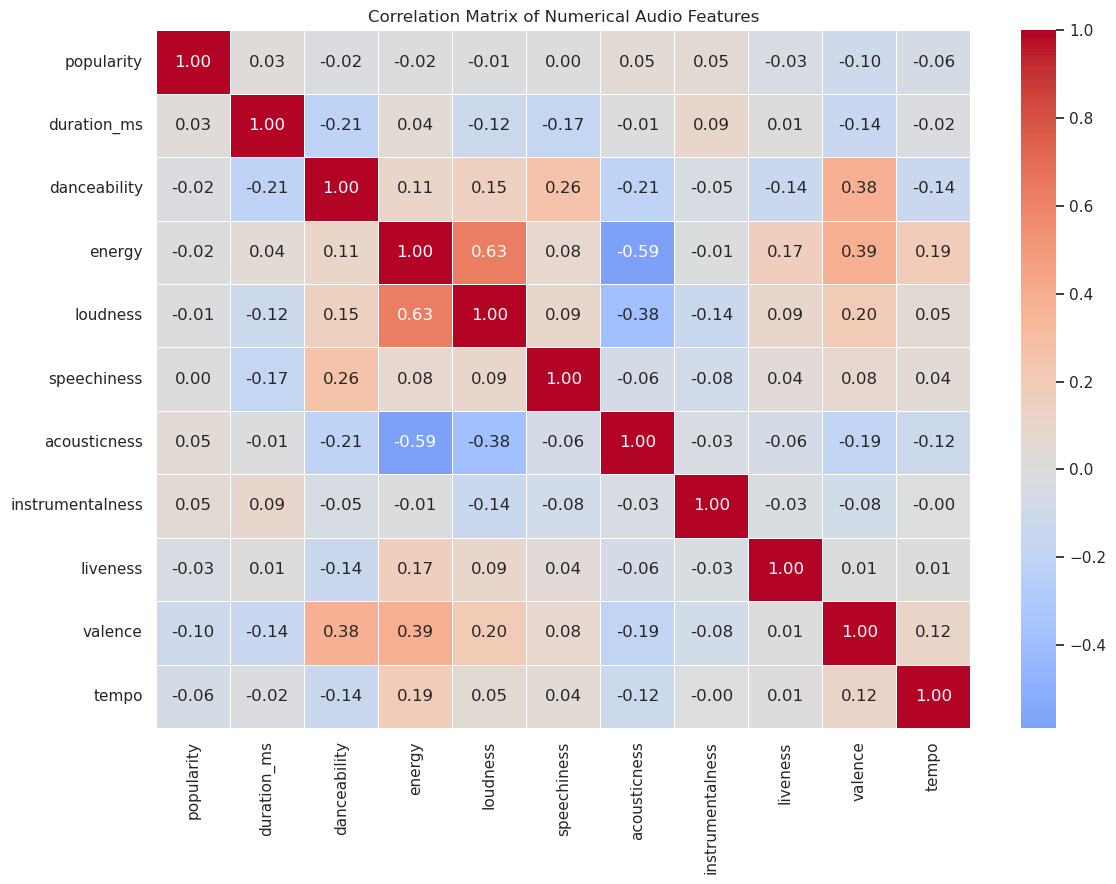

In [13]:
numerical_cols = ["popularity", "duration_ms", "danceability", "energy", "loudness",
                  "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

# were excluding the loudness outlier row
df_clean = df[df["loudness"] < 0].copy()

plt.figure(figsize=(12, 9))
corr_matrix = df_clean[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Matrix of Numerical Audio Features")
plt.tight_layout()
plt.show()

What we learned from the correlations:

- `energy` and `loudness` are strongly positively correlated, this makes sense for louder tracks to be perceived as more energetic.
- `energy` and `acousticness` are strongly negatively correlated, acoustic tracks would probably be quieter and less energetic.
- `danceability` and `valence` are moderately positively correlated, happier-sounding tracks being more dancable is reasonable.
- `popularity` shows no real single correlation with any audio feature, suggesting to us that is driven by a combination of factors includign probably external ones like marketing, fame that aren't in our dataset.

The `energy`/`loudness` correlation means these features carry overlapping information. This can be used for clustering, where redundant features can distort distance calculations.

### B.5. Pairplot of Key Audio Features

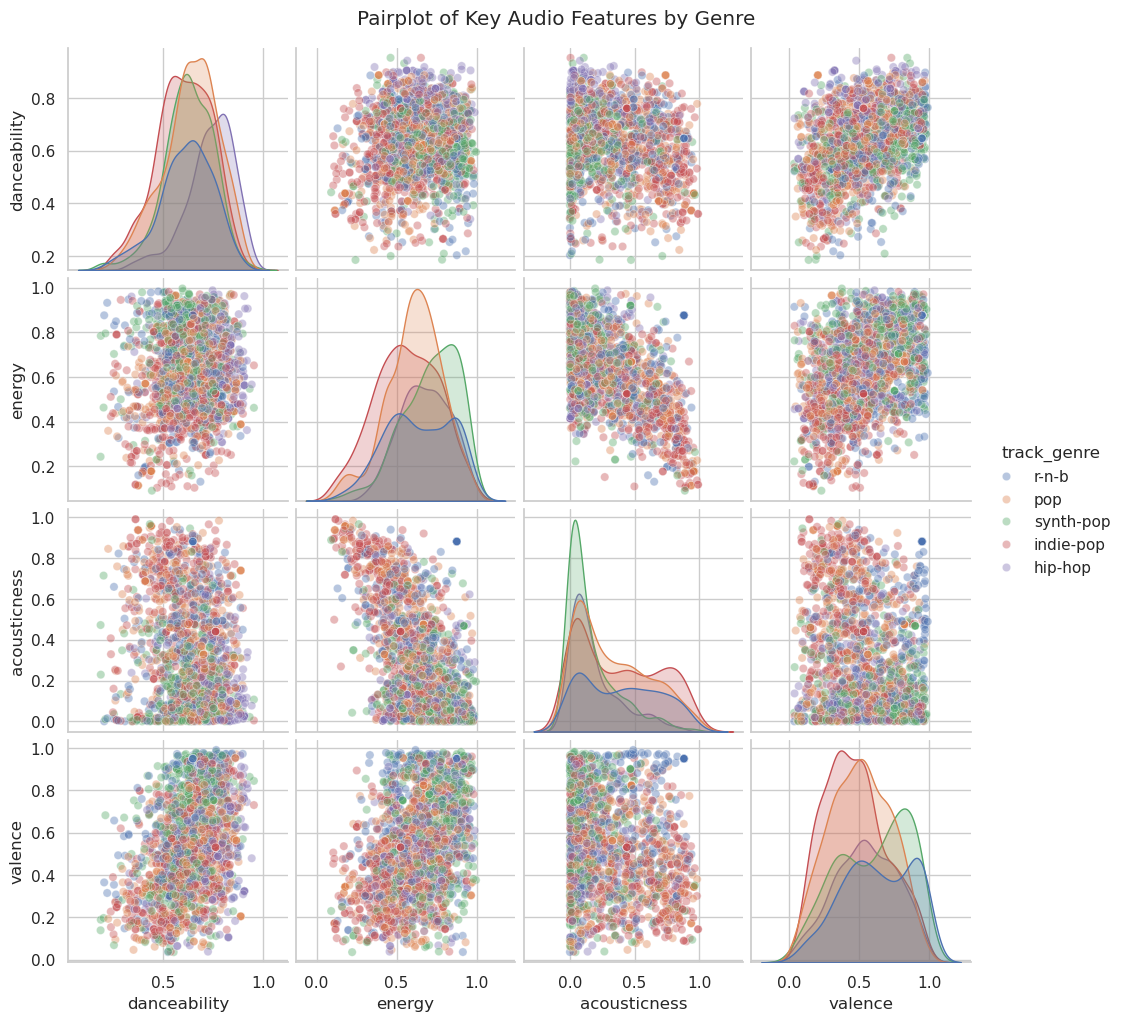

In [14]:
pairplot_cols = ["danceability", "energy", "acousticness", "valence", "track_genre"]
sns.pairplot(data=df_clean[pairplot_cols], hue="track_genre", plot_kws={"alpha": 0.4}, diag_kind="kde")
plt.suptitle("Pairplot of Key Audio Features by Genre", y=1.02)
plt.show()

The pairplot shows us a few things:
- **hip-hop** and **r-n-b** cluster towards higher danceability and lower acousticness.
- **indie-pop** has a broader spread across acousticness, overlapping significantly with other genres.
- **synth-pop** and **pop** are largely overlapping in all four dimensions, making genre-based separation difficult for these two.
- No single pair of features cleanly separates all five genres, clustering should benefit from us using the full feature set.

## C. Distribution Analysis for Numerical Attributes

### C.1. Popularity

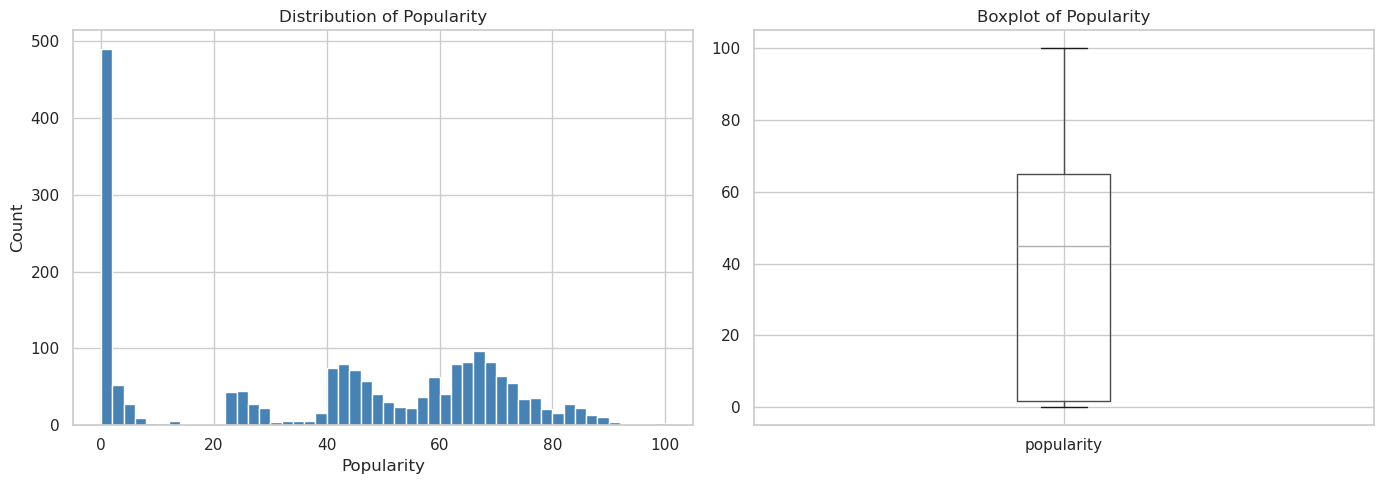

Median popularity: 45.0
Mean popularity:   39.81


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["popularity"].hist(bins=50, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_xlabel("Popularity")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Popularity")

df.boxplot(column="popularity", ax=axes[1])
axes[1].set_title("Boxplot of Popularity")

plt.tight_layout()
plt.show()

print(f"Median popularity: {df['popularity'].median()}")
print(f"Mean popularity:   {df['popularity'].mean():.2f}")

The `popularity` distribution is bimodal: a large spike near 0 (obscure or removed tracks) and a broader hump between 40–80. The median is 45, which we will use as the split threshold for the binary classification task. The bimodal shape means the median split is well-motivated there is a natural gap in the distribution rather than an arbitrary cut.

### C.2. Loudness

In [16]:
print("Loudness outliers (> 0 dB):")
print(df[df["loudness"] > 0][["track_id", "track_genre", "loudness"]])

Loudness outliers (> 0 dB):
                    track_id track_genre  loudness
1289  39ujbBjTwwqUFySaCYDMMT         pop  800000.0


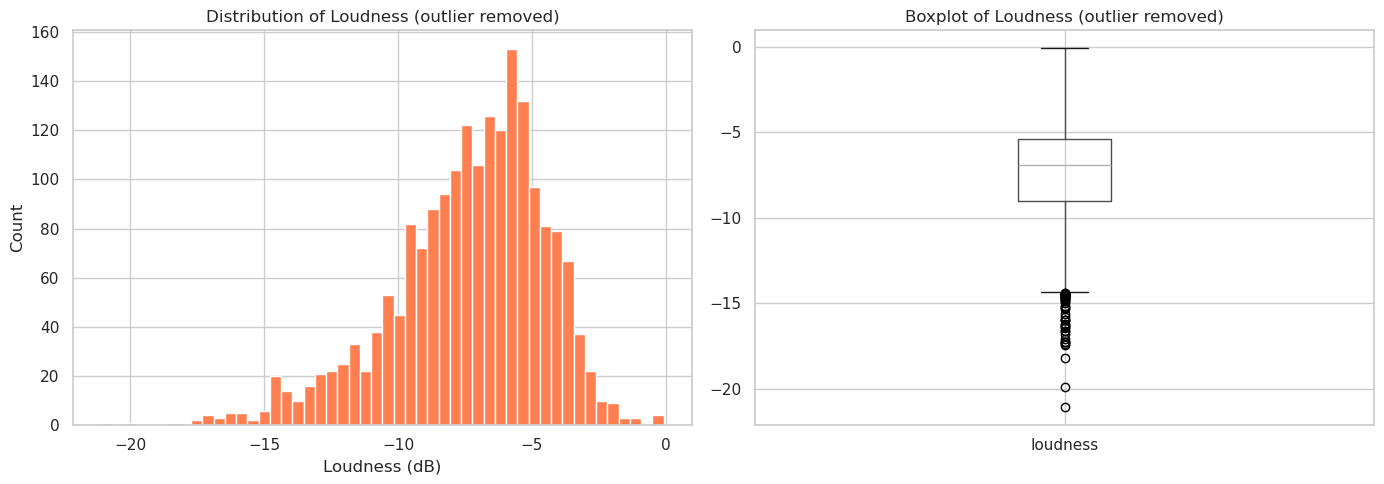

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_clean["loudness"].hist(bins=50, ax=axes[0], color="coral", edgecolor="white")
axes[0].set_xlabel("Loudness (dB)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Loudness (outlier removed)")

df_clean.boxplot(column="loudness", ax=axes[1])
axes[1].set_title("Boxplot of Loudness (outlier removed)")

plt.tight_layout()
plt.show()

After removing the loudness = 800,000 dB, the distribution is **normally distributed around −7 dB**, consistent with typical music loudness levels.

### C.3. Danceability, Energy, and Valence

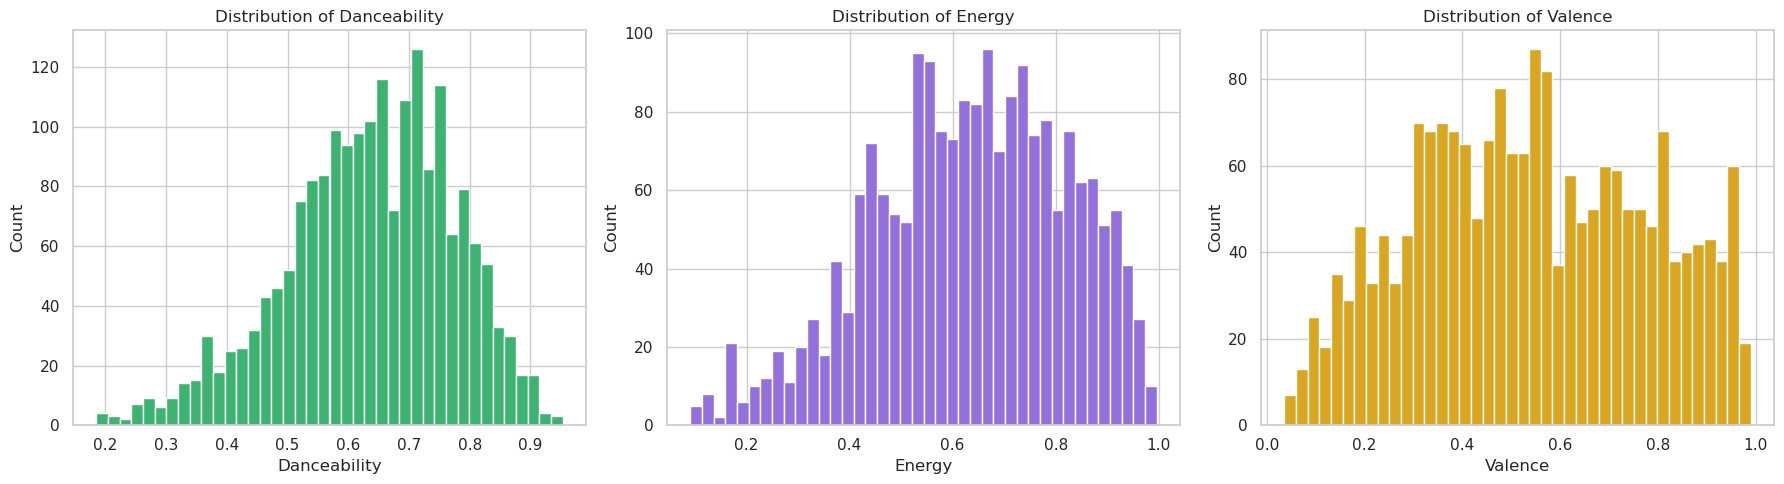

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, color in zip(axes, ["danceability", "energy", "valence"], ["mediumseagreen", "mediumpurple", "goldenrod"]):
    df_clean[col].hist(bins=40, ax=ax, color=color, edgecolor="white")
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {col.capitalize()}")

plt.tight_layout()
plt.show()

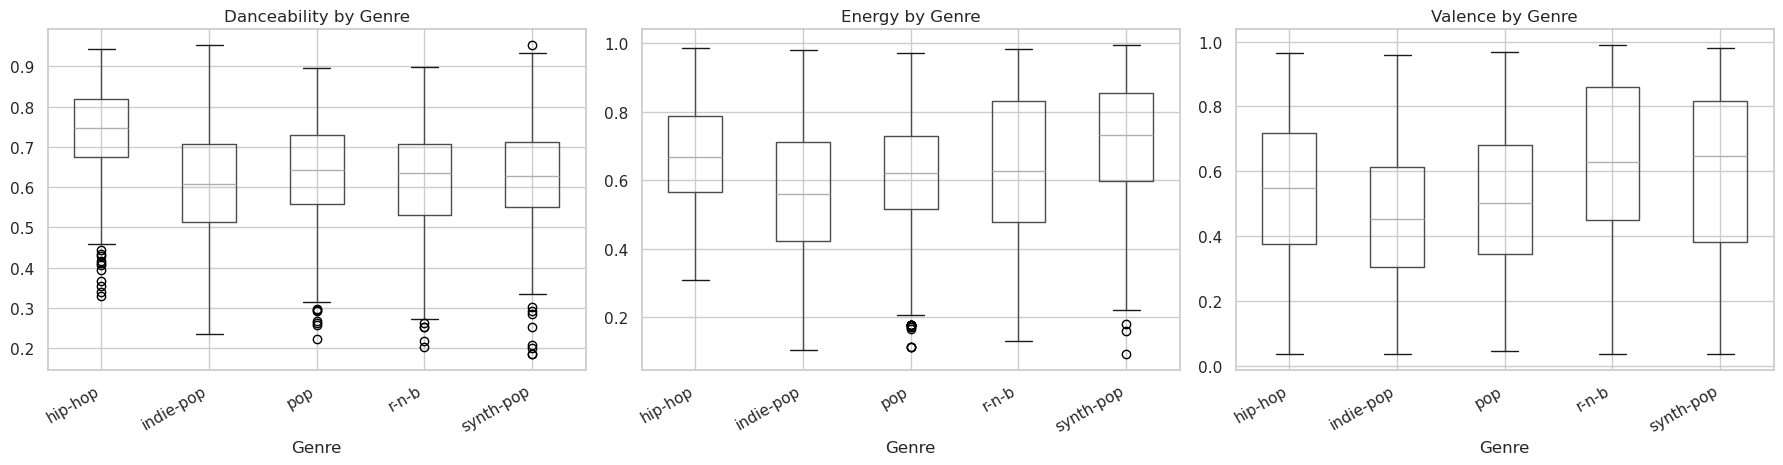

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["danceability", "energy", "valence"]):
    df_clean.boxplot(column=col, by="track_genre", ax=ax)
    ax.set_xlabel("Genre")
    ax.set_title(f"{col.capitalize()} by Genre")
    plt.sca(ax)
    plt.xticks(rotation=30, ha="right")

plt.suptitle("")
plt.tight_layout()
plt.show()

- **Danceability** is left-skewed and concentrated above 0.5. Hip-hop and r-n-b show the highest median danceability.
- **Energy** is broadly distributed, slightly left-skewed. Synth-pop and pop tend to be more energy-dense.
- **Valence** is roughly bell-shaped around 0.5 — an even split between happier and sadder-sounding tracks across all genres.

### C.4. Tempo and Duration

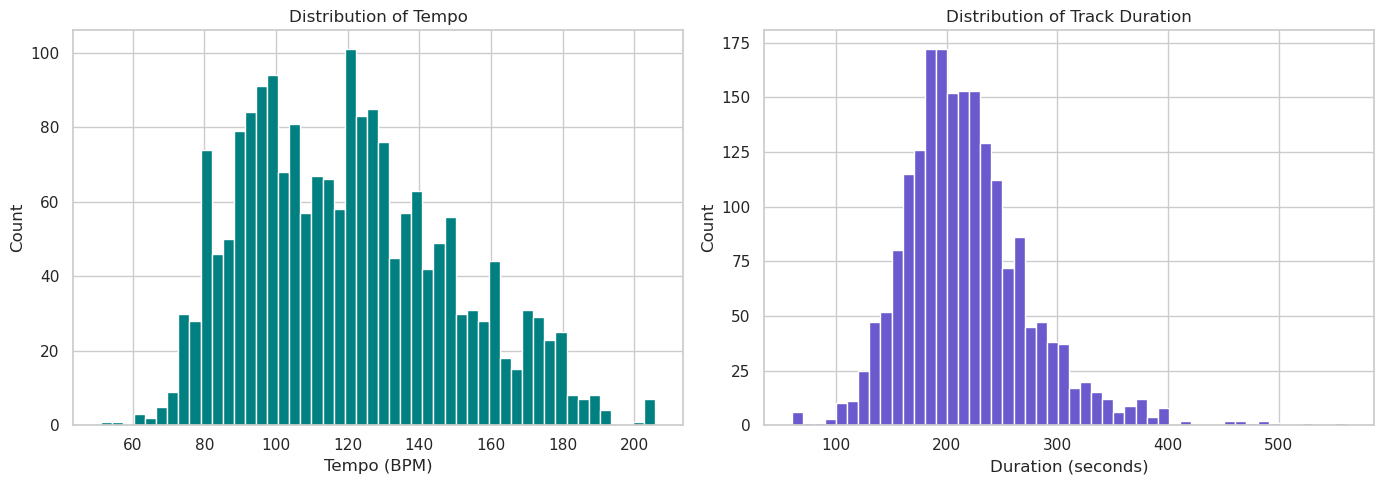

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_clean["tempo"].hist(bins=50, ax=axes[0], color="teal", edgecolor="white")
axes[0].set_xlabel("Tempo (BPM)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Tempo")

(df_clean["duration_ms"] / 1000).hist(bins=50, ax=axes[1], color="slateblue", edgecolor="white")
axes[1].set_xlabel("Duration (seconds)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Track Duration")

plt.tight_layout()
plt.show()

- **Tempo** shows a roughly bimodal distribution with peaks around ~95 BPM and ~130 BPM, common in hip-hop and pop respectively.
- **Duration** is right-skewed with most tracks between 150–300 seconds (2.5–5 min). A handful of tracks exceed 500 seconds and may be treated as outliers in regression.

### C.5. Acousticness, Instrumentalness, Speechiness, and Liveness

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

sparse_cols = ["acousticness", "instrumentalness", "speechiness", "liveness"]
colors = ["darkorange", "crimson", "royalblue", "darkgreen"]

for ax, col, color in zip(axes, sparse_cols, colors):
    df_clean[col].hist(bins=40, ax=ax, color=color, edgecolor="white")
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {col.capitalize()}")

plt.tight_layout()
plt.show()

All four features are highly right-skewed:

- Acousticness:Most tracks score low, but a meaningful secondary cluster near 1.0 exists — likely indie-pop acoustic recordings.
- Instrumentalness: Near-zero for almost all tracks — the dataset is overwhelmingly vocal, as expected for these genres.
- Speechiness: Most tracks score below 0.1. Values >0.3 are characteristic of rap/hip-hop.
- Liveness: Concentrated below 0.3 — most are studio recordings. Values above 0.8 indicate live recordings per Spotify.

The strong right skew of these features means they may benefit from log transformation before use in distance-based models (clustering, regression).

### C.6. Relationship Between Danceability and Valence

Finally, let's examine the relationship between two correlated numerical features using a scatter plot and a regression line.

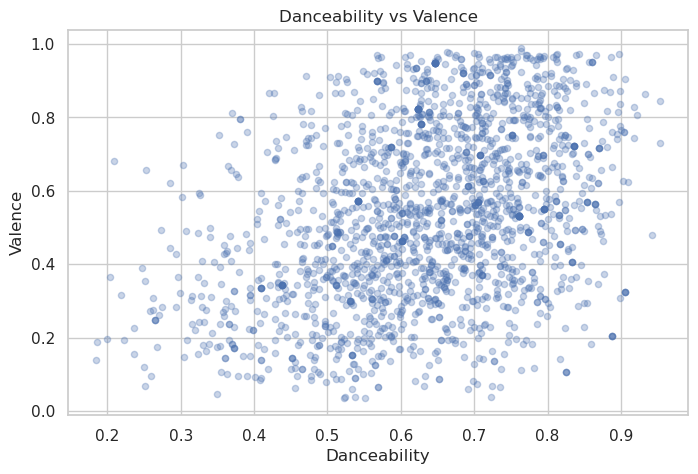

In [25]:
df_clean.plot.scatter(x='danceability', y='valence', alpha=0.3, figsize=(8, 5))
plt.xlabel('Danceability')
plt.ylabel('Valence')
plt.title('Danceability vs Valence')
plt.show()

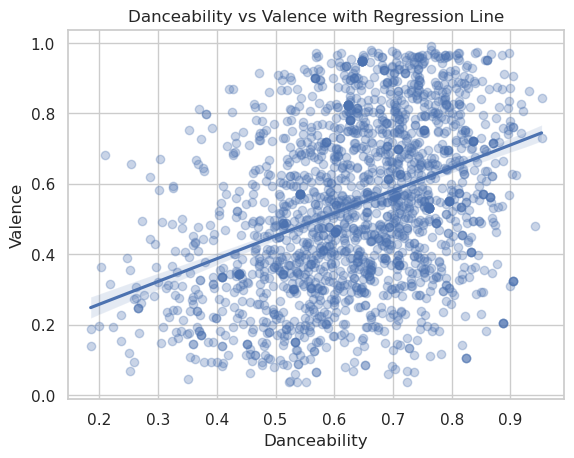

In [26]:
sns.regplot(data=df_clean, x='danceability', y='valence', scatter_kws={'alpha': 0.3})
plt.xlabel('Danceability')
plt.ylabel('Valence')
plt.title('Danceability vs Valence with Regression Line')
plt.show()

The regression line confirms a moderate positive relationship between danceability and valence. More danceable tracks tend to sound happier, consistent with the correlation matrix. However, the scatter is wide. danceability and valence are related but not interchangeable features.

## D. Violin Plot Variations by Genre

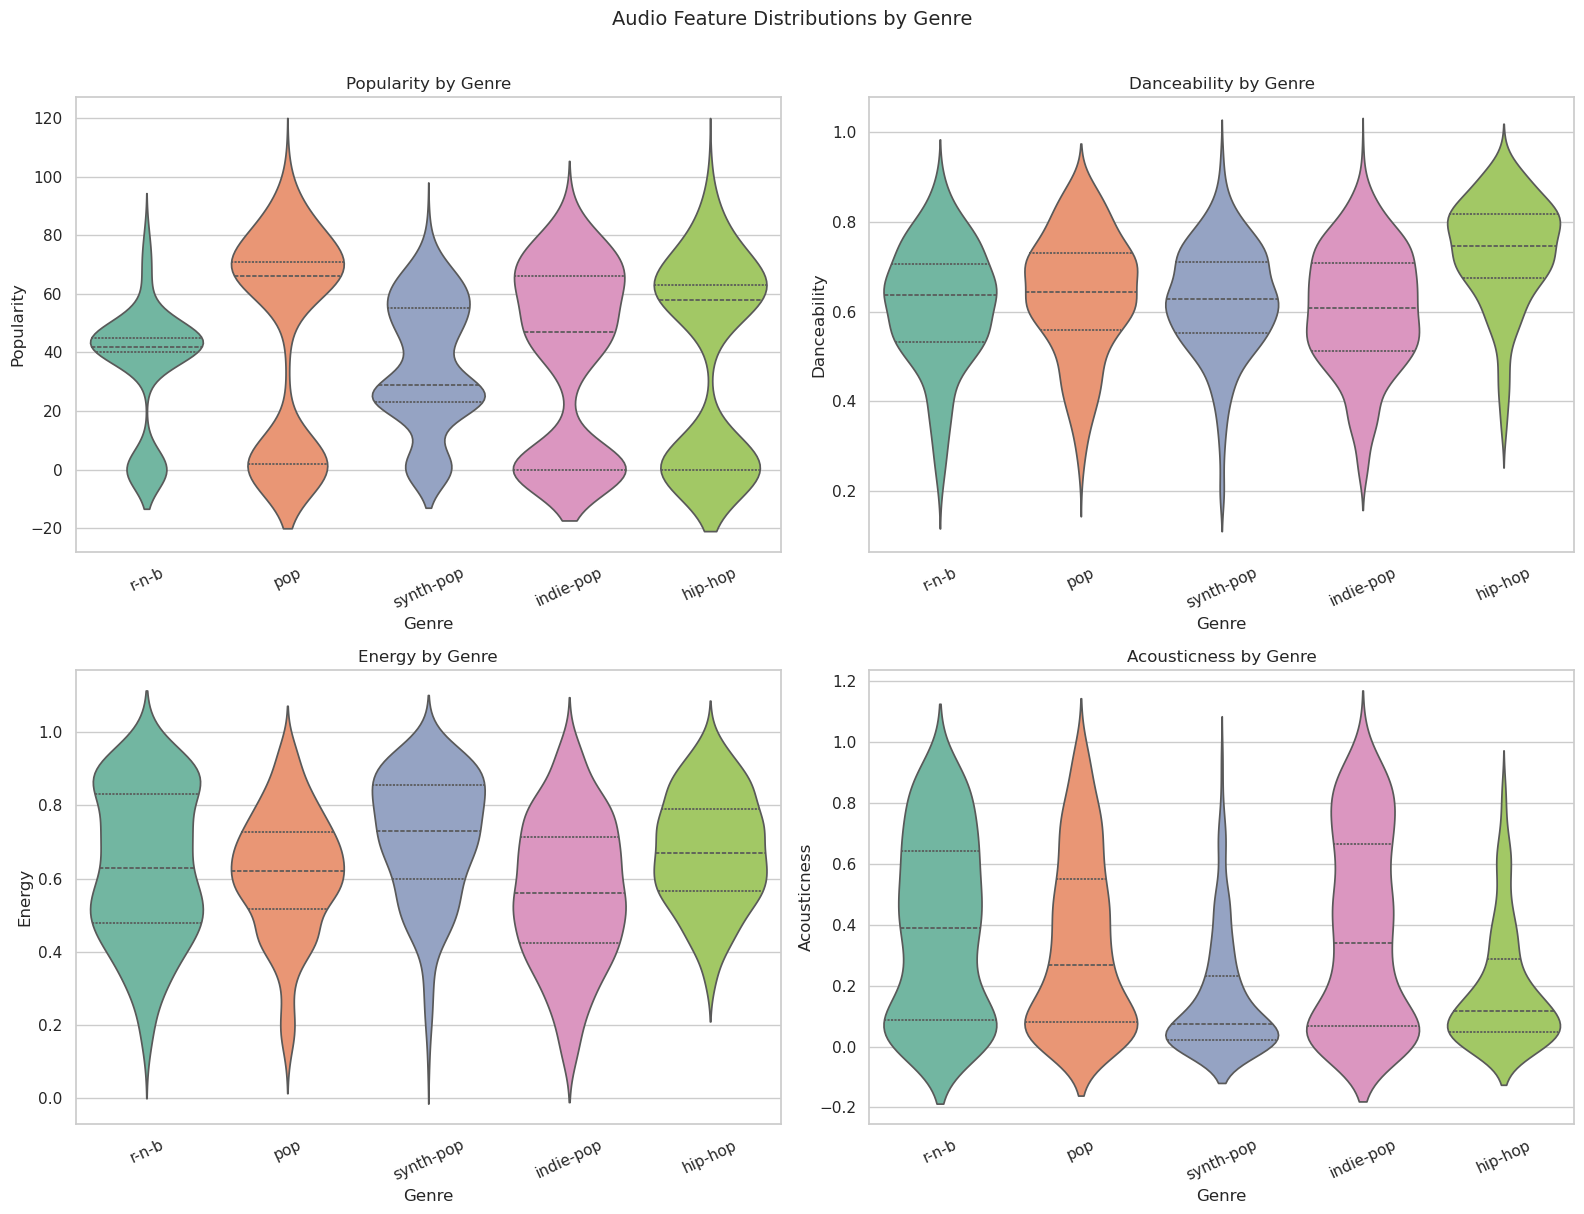

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

violin_features = ["popularity", "danceability", "energy", "acousticness"]

for ax, feat in zip(axes, violin_features):
    sns.violinplot(data=df_clean, x="track_genre", y=feat, hue="track_genre",
                   ax=ax, palette="Set2", inner="quartile", legend=False)
    ax.set_xlabel("Genre")
    ax.set_ylabel(feat.capitalize())
    ax.set_title(f"{feat.capitalize()} by Genre")
    ax.tick_params(axis="x", rotation=25)

plt.suptitle("Audio Feature Distributions by Genre", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

- Popularity: All genres show wide variance and a mass near zero. Hip-hop and pop have a slightly higher median popularity.
- Danceability: Hip-hop and r-n-b are notably more danceable. Indie-pop has the widest spread.
- Energy: Synth-pop and pop are higher energy on average. Indie-pop spans the full range.
- Acousticness: Indie-pop has a distinctly higher acousticness profile with a secondary peak near 1.0. Hip-hop and r-n-b cluster near zero.

### D.2. Strip Plot and Swarm Plot

Strip plots and swarm plots are alternatives to box/violin plots that show every individual data point, giving a clearer picture of density and overlap.

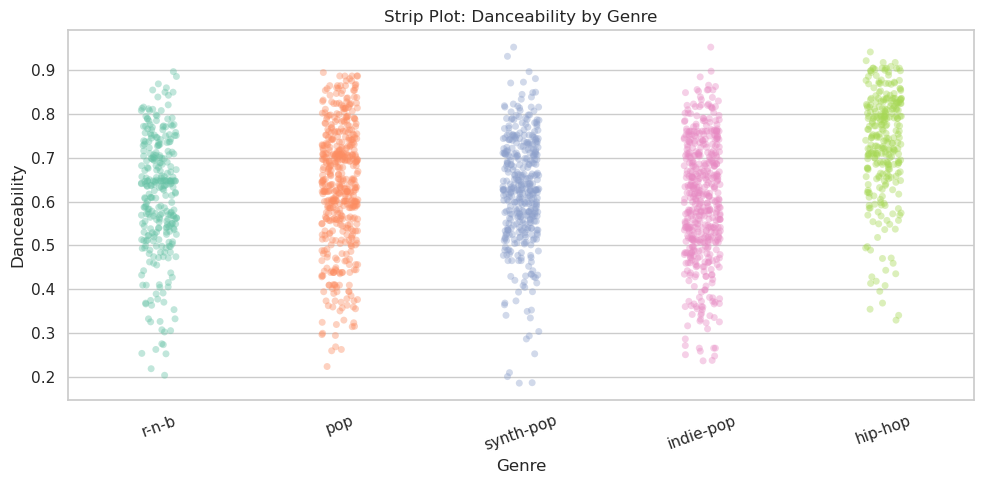

In [36]:
plt.figure(figsize=(10, 5))
sns.stripplot(data=df_clean, x="track_genre", y="danceability", hue="track_genre",
              alpha=0.4, palette="Set2", legend=False)
plt.xlabel("Genre")
plt.ylabel("Danceability")
plt.title("Strip Plot: Danceability by Genre")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

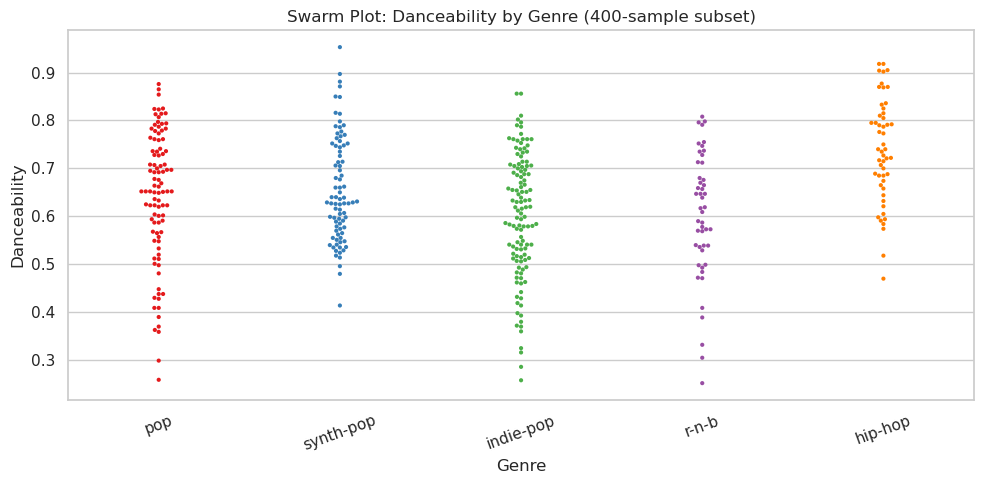

In [30]:
plt.figure(figsize=(10, 5))
sns.swarmplot(data=df_clean.sample(400, random_state=42), x="track_genre", y="danceability",
              hue="track_genre", palette="Set1", size=3, legend=False)
plt.xlabel("Genre")
plt.ylabel("Danceability")
plt.title("Swarm Plot: Danceability by Genre (400-sample subset)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The strip and swarm plots show individual track positions, making the density of each genre's danceability distribution visible at a per-point level. Hip-hop and r-n-b tracks are clearly concentrated in the upper half of the danceability range, while indie-pop tracks are spread across the full range. The swarm plot uses a subset to avoid overplotting.

### D.3. Split Violin by Explicit Content

We can split each violin by a binary attribute. Here we split danceability by genre and colour by whether the track is explicit, mirroring the lab's technique of splitting violins by a second categorical.

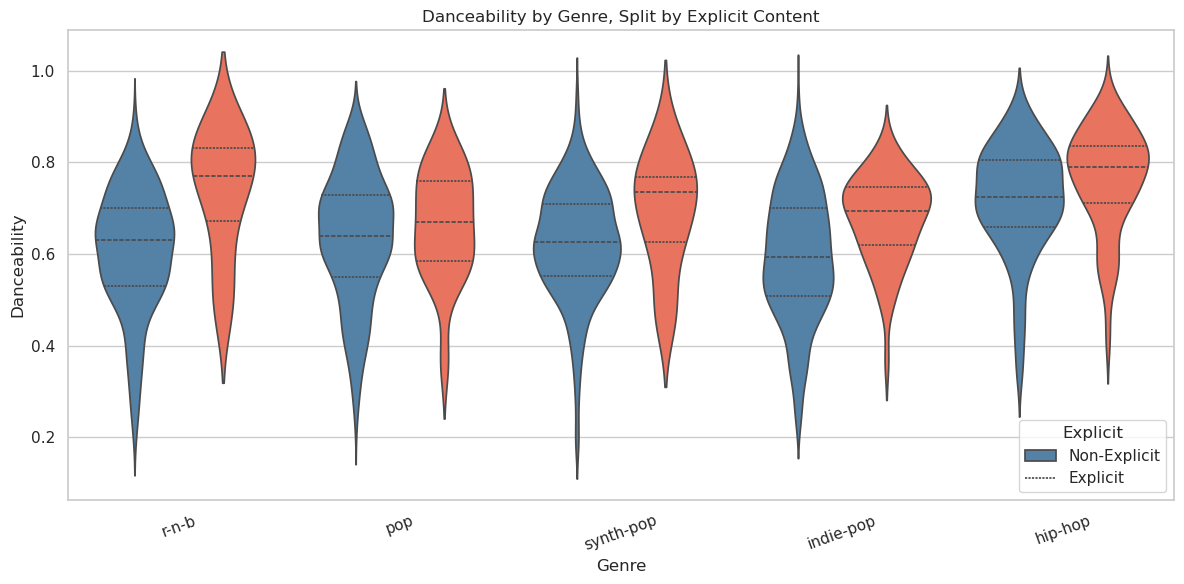

In [31]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df_clean, x='track_genre', y='danceability', hue='explicit',
               dodge="exclusive", palette=['steelblue', 'tomato'], inner='quartile')
plt.xlabel('Genre')
plt.ylabel('Danceability')
plt.title('Danceability by Genre, Split by Explicit Content')
plt.legend(title='Explicit', labels=['Non-Explicit', 'Explicit'])
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The split violin reveals that within hip-hop, explicit tracks tend to have a slightly higher and more tightly concentrated danceability compared to non-explicit hip-hop. In other genres (pop, synth-pop, indie-pop), the explicit vs non-explicit distributions are very similar, which is expected given that explicit content in those genres is relatively rare.

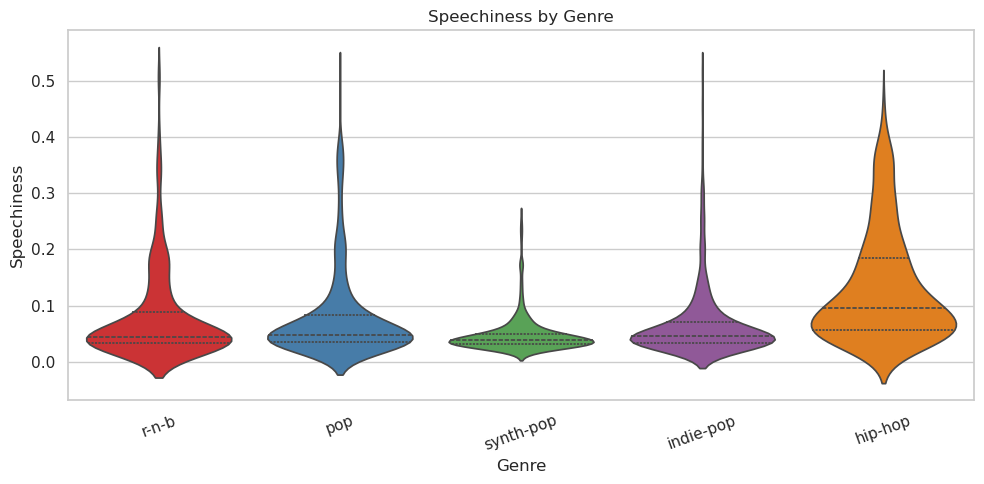

In [32]:
plt.figure(figsize=(10, 5))
sns.violinplot(data=df_clean, x="track_genre", y="speechiness", hue="track_genre",
               palette="Set1", inner="quartile", legend=False)
plt.xlabel("Genre")
plt.ylabel("Speechiness")
plt.title("Speechiness by Genre")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Speechiness** is the most discriminative single feature in this dataset: hip-hop tracks have a clearly elevated and wider distribution compared to all other genres. This is expected — rap vocals score far higher on speechiness than sung melodies. This feature will likely carry significant weight in both clustering and classification tasks.

## E. Distribution Analysis for Categorical Attributes

### E.1. Genre Distribution

Genre counts:
track_genre
pop          500
indie-pop    500
synth-pop    400
r-n-b        300
hip-hop      300
Name: count, dtype: int64


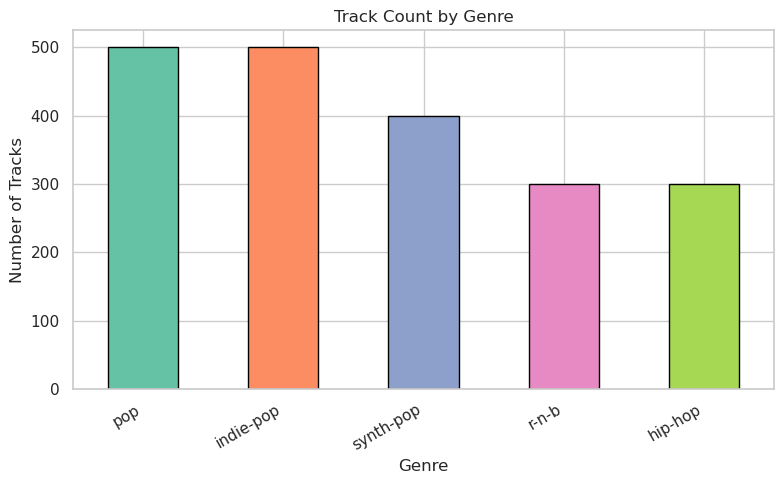

In [33]:
genre_counts = df["track_genre"].value_counts()
print("Genre counts:")
print(genre_counts)

plt.figure(figsize=(8, 5))
genre_counts.plot(kind="bar", color=sns.color_palette("Set2", len(genre_counts)), edgecolor="black")
plt.xlabel("Genre")
plt.ylabel("Number of Tracks")
plt.title("Track Count by Genre")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

The dataset is **imbalanced across genres**: pop and indie-pop each have 500 tracks (25%), synth-pop 400 (20%), r-n-b and hip-hop 300 each (15%). This imbalance matters for clustering evaluation — a solution that perfectly recovered genres would assign unequal cluster sizes. It also means genre-stratified comparisons must account for different sample sizes.

### E.2. Explicit Content

Explicit track counts:
explicit
False    1777
True      223
Name: count, dtype: int64
Proportion explicit: 11.2%


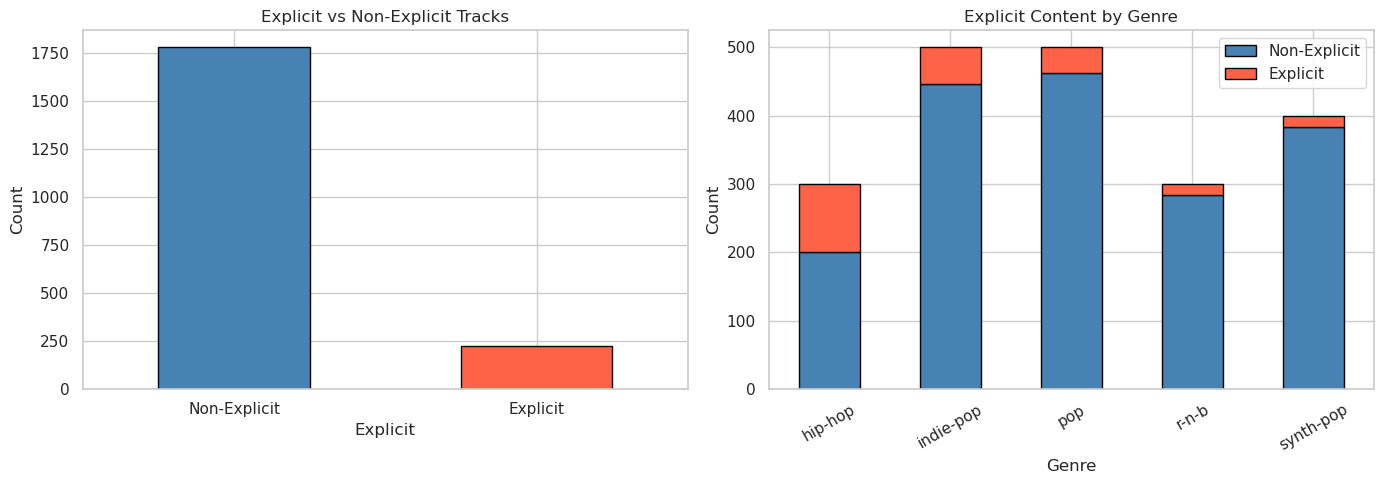

In [35]:
explicit_counts = df["explicit"].value_counts()
print("Explicit track counts:")
print(explicit_counts)
print(f"Proportion explicit: {explicit_counts[True]/len(df)*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

explicit_counts.plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_xlabel("Explicit")
axes[0].set_ylabel("Count")
axes[0].set_title("Explicit vs Non-Explicit Tracks")
axes[0].set_xticklabels(["Non-Explicit", "Explicit"], rotation=0)

crosstab_eg = pd.crosstab(df["track_genre"], df["explicit"])
crosstab_eg.plot(kind="bar", stacked=True, ax=axes[1], color=["steelblue", "tomato"], edgecolor="black")
axes[1].set_xlabel("Genre")
axes[1].set_ylabel("Count")
axes[1].set_title("Explicit Content by Genre")
axes[1].legend(["Non-Explicit", "Explicit"])
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Only ~11% of tracks are explicit overall. However, hip-hop has a disproportionately high rate of explicit content compared to pop, indie-pop, and synth-pop. This makes `explicit` a genre-correlated feature that could be informative for clustering and classification, but should be interpreted cautiously to avoid confounding genre effects with popularity effects.

### E.3. Mode and Key

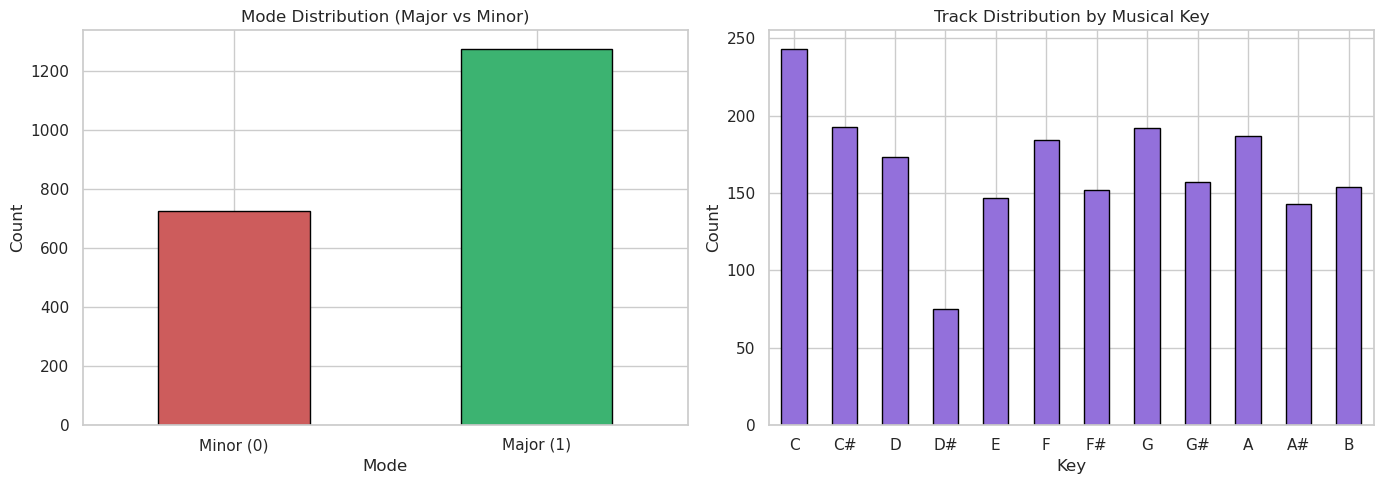

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mode_counts = df["mode"].value_counts().sort_index()
mode_counts.index = ["Minor (0)", "Major (1)"]
mode_counts.plot(kind="bar", ax=axes[0], color=["indianred", "mediumseagreen"], edgecolor="black")
axes[0].set_xlabel("Mode")
axes[0].set_ylabel("Count")
axes[0].set_title("Mode Distribution (Major vs Minor)")
axes[0].tick_params(axis="x", rotation=0)

key_counts = df["key"].value_counts().sort_index()
key_labels = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
key_counts.index = key_labels
key_counts.plot(kind="bar", ax=axes[1], color="mediumpurple", edgecolor="black")
axes[1].set_xlabel("Key")
axes[1].set_ylabel("Count")
axes[1].set_title("Track Distribution by Musical Key")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

- Mode: ~64% of tracks are in a major key, consistent with the broader prevalence of major-key music in popular genres.
- Key: The distribution is uneven — C is the most common, while D# is underrepresented, a well-known pattern in Western popular music.

### E.4. Popularity by Genre — Pivot Table

In [40]:
pivot_pop_genre = df.pivot_table(values="popularity", index="track_genre", aggfunc=["mean", "median", "std"])
pivot_pop_genre.columns = ["Mean Popularity", "Median Popularity", "Std Popularity"]
pivot_pop_genre.sort_values("Median Popularity", ascending=False)

,Mean Popularity,Median Popularity,Std Popularity
track_genre,,,
pop,46.190574,66.0,34.553392
hip-hop,38.407534,58.0,32.693437
indie-pop,39.663968,47.0,30.028527
r-n-b,35.894198,42.0,20.826725
synth-pop,36.007634,29.0,21.503736


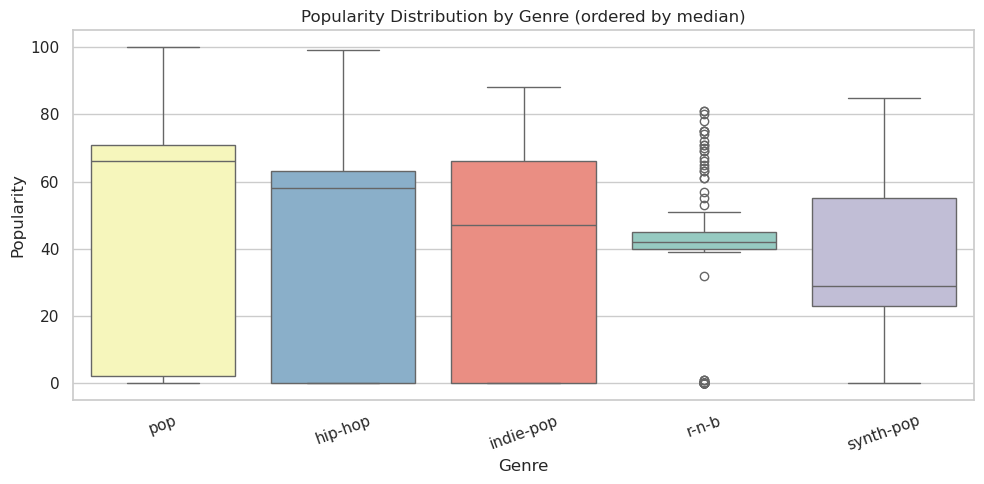

In [38]:
genre_order = df.groupby("track_genre")["popularity"].median().sort_values(ascending=False).index
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x="track_genre", y="popularity", hue="track_genre",
            palette="Set3", order=genre_order, legend=False)
plt.xlabel("Genre")
plt.ylabel("Popularity")
plt.title("Popularity Distribution by Genre (ordered by median)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Genre has a measurable but modest effect on popularity. Hip-hop and pop have slightly higher median popularity, but all genres exhibit very wide variance. The large within-genre spread confirms that audio features alone are imperfect predictors of popularity and that predicting the exact score (regression) will be harder than predicting high/low (classification).

### E.5. Explicit Content vs Popularity

In [ ]:
pivot_pop_explicit = df.pivot_table(values="popularity", index="explicit", aggfunc=["mean", "median"])
pivot_pop_explicit.index = ["Non-Explicit", "Explicit"]
pivot_pop_explicit.columns = ["Mean Popularity", "Median Popularity"]
print(pivot_pop_explicit)

plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x="explicit", y="popularity", hue="explicit",
            palette=["steelblue", "tomato"], legend=False)
plt.xticks([0, 1], ["Non-Explicit", "Explicit"])
plt.xlabel("Explicit")
plt.ylabel("Popularity")
plt.title("Popularity: Explicit vs Non-Explicit Tracks")
plt.tight_layout()
plt.show()

Explicit tracks have a noticeably higher median popularity than non-explicit tracks. This could be from genre hip-hop (the most explicit genre) also tends to be more popular in the dataset. This relationship should be interpreted cautiously rather than causally.